<a href="https://colab.research.google.com/github/hanaafrin1/codsoft/blob/main/Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving Titanic-Dataset.csv to Titanic-Dataset (2).csv
✅ Dataset loaded: (891, 12)
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803

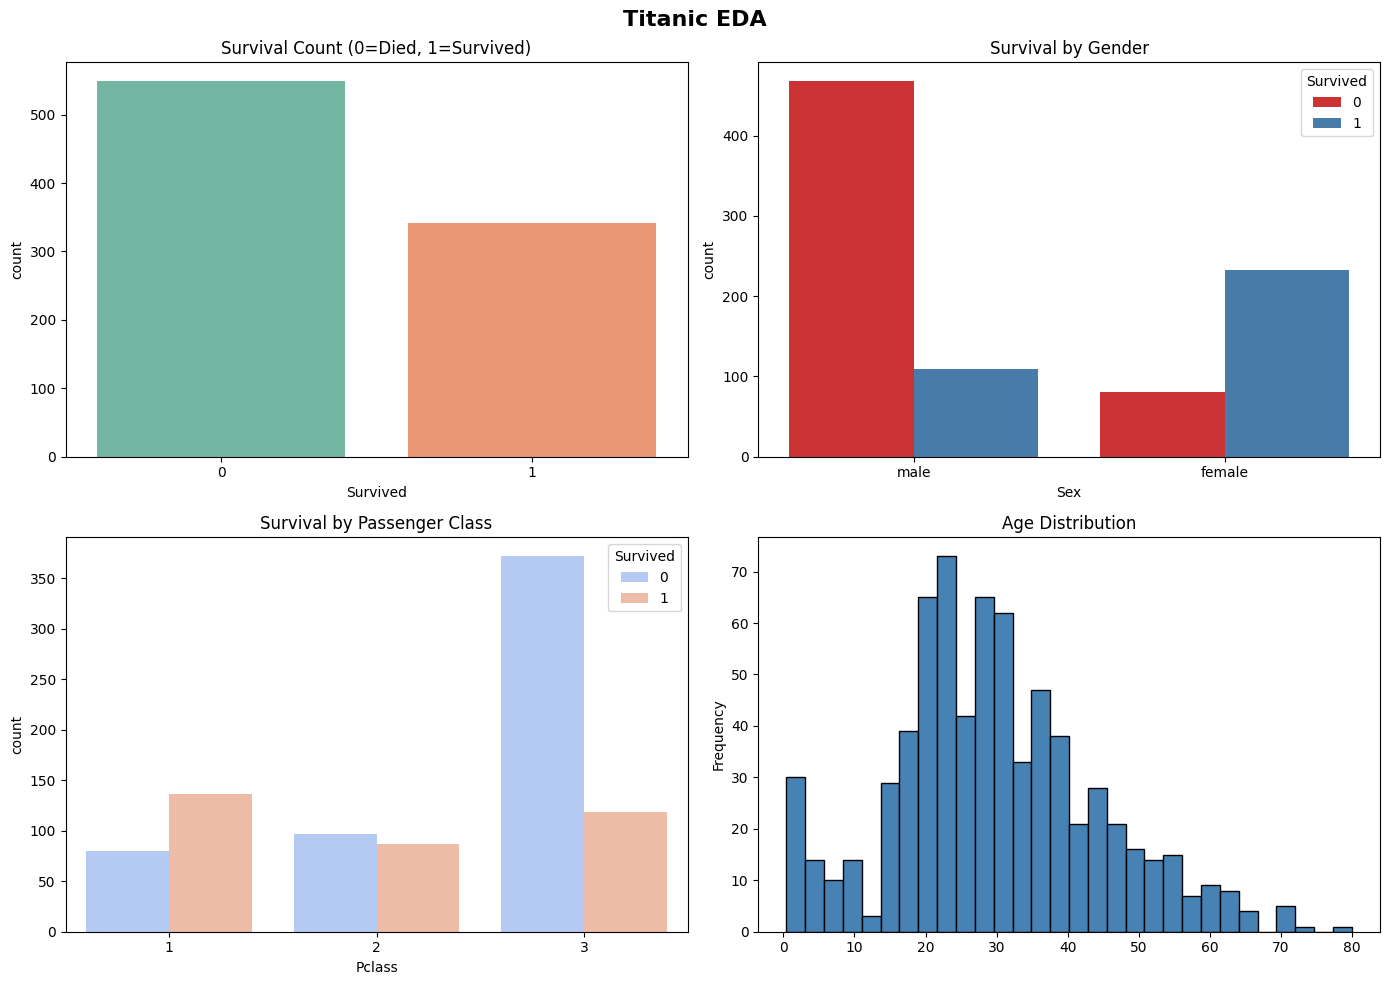

✅ EDA plots saved!

✅ After preprocessing — missing values:
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64
   Survived  Pclass  Sex   Age  SibSp  Parch     Fare  Embarked
0         0       3    1  22.0      1      0   7.2500         0
1         1       1    0  38.0      1      0  71.2833         1
2         1       3    0  26.0      0      0   7.9250         0
3         1       1    0  35.0      1      0  53.1000         0
4         0       3    1  35.0      0      0   8.0500         0

📐 Train: 712 rows | Test: 179 rows

🔵 Logistic Regression Accuracy : 80.45%
🟢 Random Forest Accuracy       : 82.12%

📊 Classification Report (Random Forest):
              precision    recall  f1-score   support

        Died       0.84      0.88      0.86       110
    Survived       0.79      0.72      0.76        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.81       179


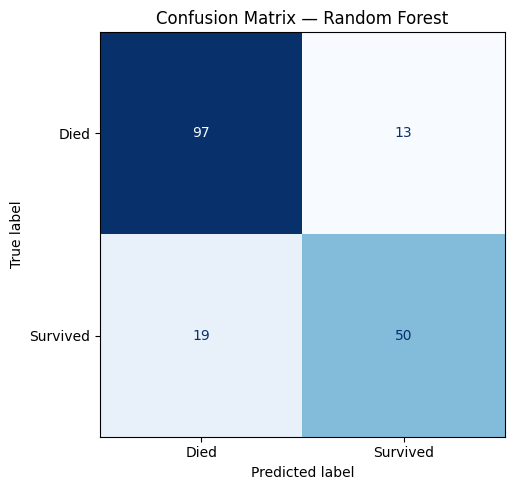

✅ Confusion matrix saved!


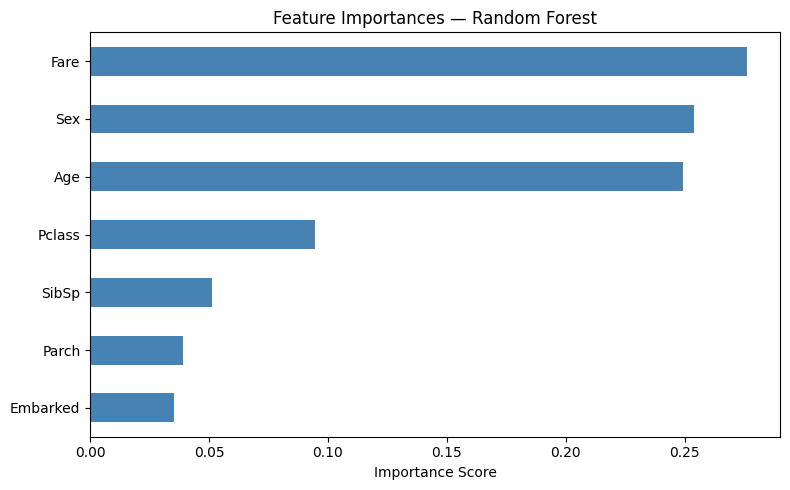

✅ Feature importance saved!

🚢 Custom Passenger Prediction:
   Result      : ❌ DID NOT SURVIVE
   Probability : Died=98.0% | Survived=2.0%

🎉 Task 1 Complete!


In [4]:
# =============================================================
# TASK 1 - TITANIC SURVIVAL PREDICTION
# CodSoft Data Science Internship
# Dataset: Titanic-Dataset.csv (891 rows, 12 columns)
# =============================================================

# ── STEP 1: Upload & Load Dataset ────────────────────────────
from google.colab import files
import io, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")

uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))
print("✅ Dataset loaded:", df.shape)
print(df.head())


# ── STEP 2: EDA ───────────────────────────────────────────────
print("\n📋 Missing Values:")
print(df.isnull().sum())

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Titanic EDA', fontsize=16, fontweight='bold')

sns.countplot(x='Survived', data=df, palette='Set2', ax=axes[0,0])
axes[0,0].set_title('Survival Count (0=Died, 1=Survived)')

sns.countplot(x='Sex', hue='Survived', data=df, palette='Set1', ax=axes[0,1])
axes[0,1].set_title('Survival by Gender')

sns.countplot(x='Pclass', hue='Survived', data=df, palette='coolwarm', ax=axes[1,0])
axes[1,0].set_title('Survival by Passenger Class')

df['Age'].dropna().plot(kind='hist', bins=30, color='steelblue',
                        edgecolor='black', ax=axes[1,1])
axes[1,1].set_title('Age Distribution')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA plots saved!")


# ── STEP 3: Preprocessing ────────────────────────────────────
df_model = df.copy()

# Drop columns not useful for prediction
df_model.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'], inplace=True)

# Fill missing values
df_model['Age'].fillna(df_model['Age'].median(), inplace=True)
df_model['Embarked'].fillna(df_model['Embarked'].mode()[0], inplace=True)
df_model['Fare'].fillna(df_model['Fare'].median(), inplace=True)

# Encode categorical columns
df_model['Sex']      = df_model['Sex'].map({'male': 1, 'female': 0})
df_model['Embarked'] = df_model['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

print("\n✅ After preprocessing — missing values:")
print(df_model.isnull().sum())
print(df_model.head())


# ── STEP 4: Train / Test Split ───────────────────────────────
from sklearn.model_selection import train_test_split

X = df_model.drop(columns=['Survived'])
y = df_model['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\n📐 Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")


# ── STEP 5: Train Models ──────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
lr_acc = accuracy_score(y_test, lr.predict(X_test))

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_preds)

print(f"\n🔵 Logistic Regression Accuracy : {lr_acc*100:.2f}%")
print(f"🟢 Random Forest Accuracy       : {rf_acc*100:.2f}%")


# ── STEP 6: Evaluate ─────────────────────────────────────────
print("\n📊 Classification Report (Random Forest):")
print(classification_report(y_test, rf_preds, target_names=['Died','Survived']))

cm = confusion_matrix(y_test, rf_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=['Died','Survived'])
fig, ax = plt.subplots(figsize=(6,5))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Random Forest')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Confusion matrix saved!")


# ── STEP 7: Feature Importance ───────────────────────────────
feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(8,5))
feat_imp.plot(kind='barh', color='steelblue', ax=ax)
ax.set_title('Feature Importances — Random Forest')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Feature importance saved!")


# ── STEP 8: Predict a Custom Passenger ───────────────────────
# 3rd class male, age 22, alone, fare 7.25, embarked S
new_passenger = pd.DataFrame({
    'Pclass':   [3],
    'Sex':      [1],    # 1=male
    'Age':      [22],
    'SibSp':    [0],
    'Parch':    [0],
    'Fare':     [7.25],
    'Embarked': [0]     # 0=S
})

pred = rf.predict(new_passenger)[0]
prob = rf.predict_proba(new_passenger)[0]
print(f"\n🚢 Custom Passenger Prediction:")
print(f"   Result      : {'✅ SURVIVED' if pred==1 else '❌ DID NOT SURVIVE'}")
print(f"   Probability : Died={prob[0]*100:.1f}% | Survived={prob[1]*100:.1f}%")

print("\n🎉 Task 1 Complete!")


Saving Titanic-Dataset.csv to Titanic-Dataset (2).csv
✅ Dataset loaded: (891, 12)
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803

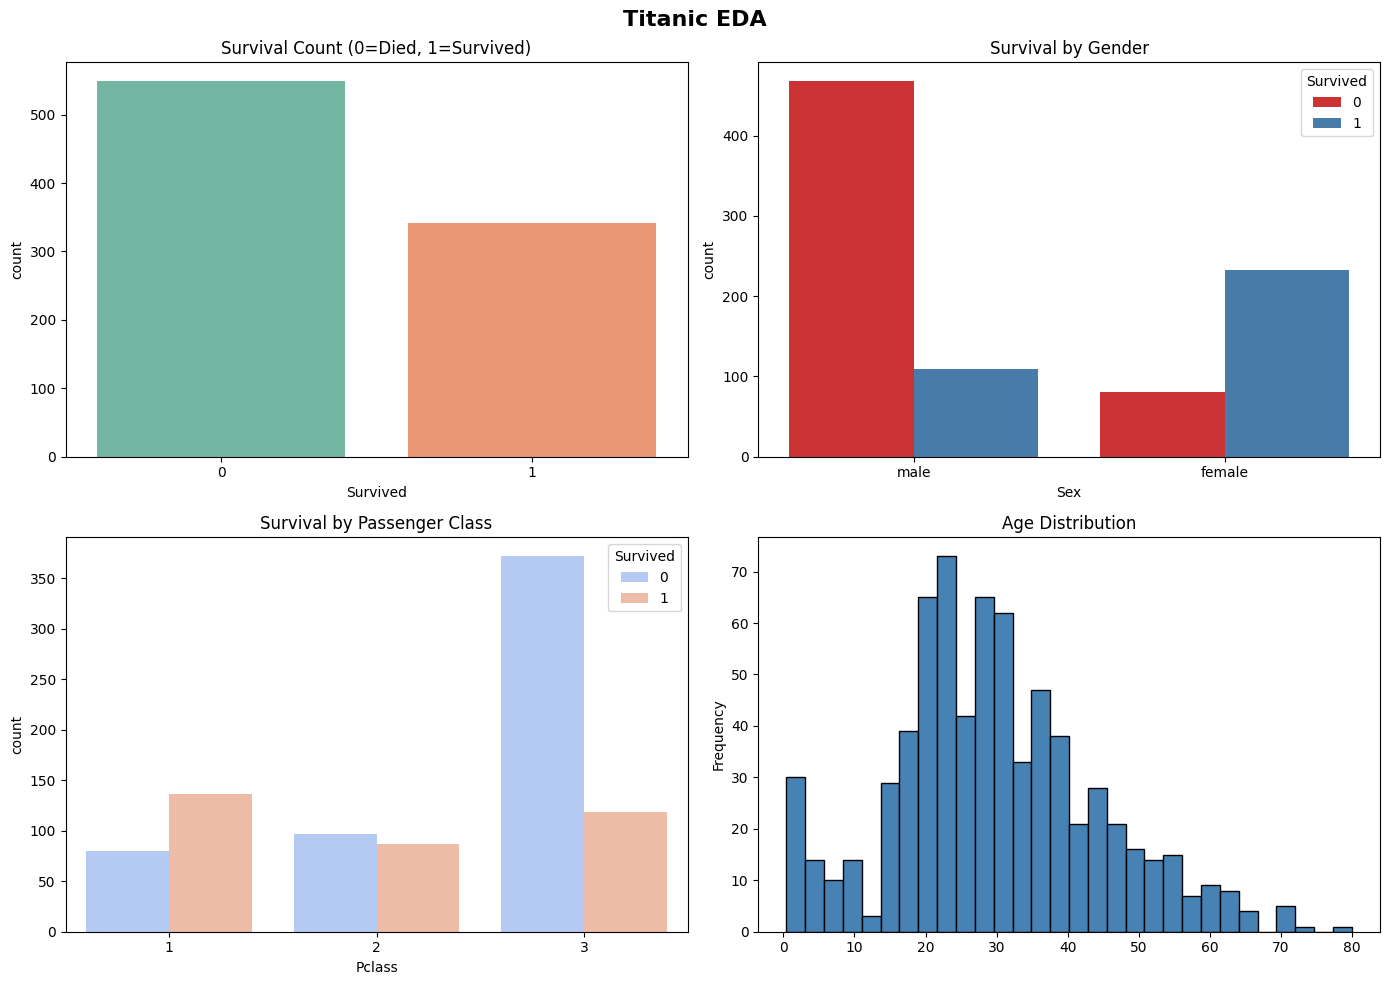

✅ EDA plots saved!

✅ After preprocessing — missing values:
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64
   Survived  Pclass  Sex   Age  SibSp  Parch     Fare  Embarked
0         0       3    1  22.0      1      0   7.2500         0
1         1       1    0  38.0      1      0  71.2833         1
2         1       3    0  26.0      0      0   7.9250         0
3         1       1    0  35.0      1      0  53.1000         0
4         0       3    1  35.0      0      0   8.0500         0

📐 Train: 712 rows | Test: 179 rows

🔵 Logistic Regression Accuracy : 80.45%
🟢 Random Forest Accuracy       : 82.12%

📊 Classification Report (Random Forest):
              precision    recall  f1-score   support

        Died       0.84      0.88      0.86       110
    Survived       0.79      0.72      0.76        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.81       179


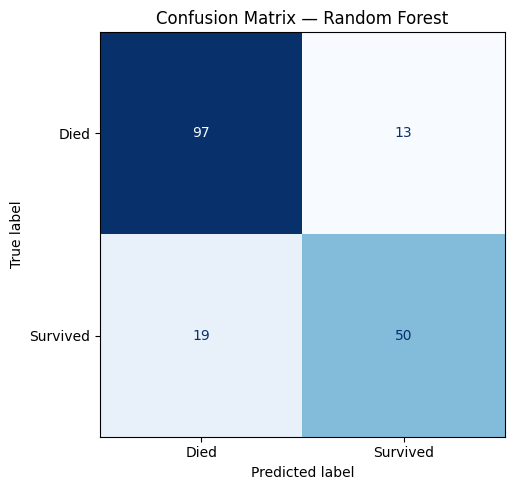

✅ Confusion matrix saved!


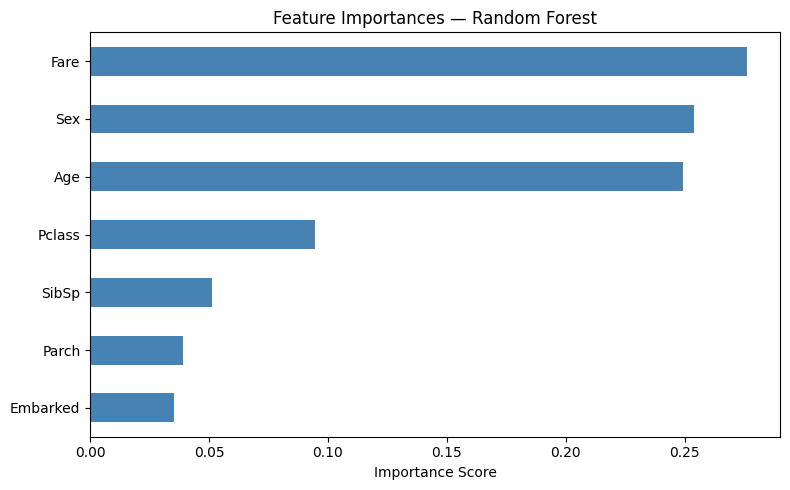

✅ Feature importance saved!

🚢 Custom Passenger Prediction:
   Result      : ❌ DID NOT SURVIVE
   Probability : Died=98.0% | Survived=2.0%

🎉 Task 1 Complete!


In [ ]:
# =============================================================
# TASK 1 - TITANIC SURVIVAL PREDICTION
# CodSoft Data Science Internship
# Dataset: Titanic-Dataset.csv (891 rows, 12 columns)
# =============================================================

# ── STEP 1: Upload & Load Dataset ────────────────────────────
from google.colab import files
import io, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")

uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))
print("✅ Dataset loaded:", df.shape)
print(df.head())


# ── STEP 2: EDA ───────────────────────────────────────────────
print("\n📋 Missing Values:")
print(df.isnull().sum())

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Titanic EDA', fontsize=16, fontweight='bold')

sns.countplot(x='Survived', data=df, palette='Set2', ax=axes[0,0])
axes[0,0].set_title('Survival Count (0=Died, 1=Survived)')

sns.countplot(x='Sex', hue='Survived', data=df, palette='Set1', ax=axes[0,1])
axes[0,1].set_title('Survival by Gender')

sns.countplot(x='Pclass', hue='Survived', data=df, palette='coolwarm', ax=axes[1,0])
axes[1,0].set_title('Survival by Passenger Class')

df['Age'].dropna().plot(kind='hist', bins=30, color='steelblue',
                        edgecolor='black', ax=axes[1,1])
axes[1,1].set_title('Age Distribution')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA plots saved!")


# ── STEP 3: Preprocessing ────────────────────────────────────
df_model = df.copy()

# Drop columns not useful for prediction
df_model.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'], inplace=True)

# Fill missing values
df_model['Age'].fillna(df_model['Age'].median(), inplace=True)
df_model['Embarked'].fillna(df_model['Embarked'].mode()[0], inplace=True)
df_model['Fare'].fillna(df_model['Fare'].median(), inplace=True)

# Encode categorical columns
df_model['Sex']      = df_model['Sex'].map({'male': 1, 'female': 0})
df_model['Embarked'] = df_model['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

print("\n✅ After preprocessing — missing values:")
print(df_model.isnull().sum())
print(df_model.head())


# ── STEP 4: Train / Test Split ───────────────────────────────
from sklearn.model_selection import train_test_split

X = df_model.drop(columns=['Survived'])
y = df_model['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\n📐 Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")


# ── STEP 5: Train Models ──────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
lr_acc = accuracy_score(y_test, lr.predict(X_test))

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_preds)

print(f"\n🔵 Logistic Regression Accuracy : {lr_acc*100:.2f}%")
print(f"🟢 Random Forest Accuracy       : {rf_acc*100:.2f}%")


# ── STEP 6: Evaluate ─────────────────────────────────────────
print("\n📊 Classification Report (Random Forest):")
print(classification_report(y_test, rf_preds, target_names=['Died','Survived']))

cm = confusion_matrix(y_test, rf_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=['Died','Survived'])
fig, ax = plt.subplots(figsize=(6,5))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Random Forest')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Confusion matrix saved!")


# ── STEP 7: Feature Importance ───────────────────────────────
feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(8,5))
feat_imp.plot(kind='barh', color='steelblue', ax=ax)
ax.set_title('Feature Importances — Random Forest')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Feature importance saved!")


# ── STEP 8: Predict a Custom Passenger ───────────────────────
# 3rd class male, age 22, alone, fare 7.25, embarked S
new_passenger = pd.DataFrame({
    'Pclass':   [3],
    'Sex':      [1],    # 1=male
    'Age':      [22],
    'SibSp':    [0],
    'Parch':    [0],
    'Fare':     [7.25],
    'Embarked': [0]     # 0=S
})

pred = rf.predict(new_passenger)[0]
prob = rf.predict_proba(new_passenger)[0]
print(f"\n🚢 Custom Passenger Prediction:")
print(f"   Result      : {'✅ SURVIVED' if pred==1 else '❌ DID NOT SURVIVE'}")
print(f"   Probability : Died={prob[0]*100:.1f}% | Survived={prob[1]*100:.1f}%")

print("\n🎉 Task 1 Complete!")
